# 31. Alpha Recovery & Robust Ensemble Pipeline

## Objective
Recover Step-28 signal quality and improve robustness using a leakage-safe, rank-preserving, IC-driven ensemble.

**Hard constraints enforced:**
- no residual-target replacement
- no fixed blind averaging
- no time smoothing
- no synthetic sector clustering
- no leakage (only information available up to time `t` in features)

In [1]:
from __future__ import annotations

from pathlib import Path
from typing import Dict, List, Tuple
import logging

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import spearmanr
from xgboost import XGBRegressor

try:
    from IPython.display import display
except Exception:
    def display(x):
        print(x)

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 300)
pd.set_option('display.width', 240)

TRAIN_START = pd.Timestamp('2023-01-01')
TRAIN_END = pd.Timestamp('2024-12-31')
TEST_START = pd.Timestamp('2025-01-01')
TEST_END = pd.Timestamp('2025-12-31')

TOP_N = 10
ANNUALIZATION_DAYS = 252
RANDOM_STATE = 42

logger = logging.getLogger('step31_alpha_recovery')
if not logger.handlers:
    h = logging.StreamHandler()
    h.setFormatter(logging.Formatter('[%(levelname)s] %(message)s'))
    logger.addHandler(h)
logger.setLevel(logging.INFO)


In [2]:
def resolve_project_root() -> Path:
    cwd = Path.cwd()
    for c in [cwd, cwd.parent, cwd.parent.parent]:
        if (c / 'ml_pipeline').exists() and (c / 'CLAUDE.md').exists():
            return c
    raise FileNotFoundError('Unable to locate project root.')


def cs_zscore(s: pd.Series) -> pd.Series:
    sd = s.std(ddof=0)
    if pd.isna(sd) or sd == 0:
        return pd.Series(0.0, index=s.index)
    return (s - s.mean()) / sd


def sharpe_ratio(daily_returns: pd.Series, annualization: int = ANNUALIZATION_DAYS) -> float:
    mu = float(daily_returns.mean())
    sigma = float(daily_returns.std(ddof=1))
    if sigma == 0.0 or np.isnan(sigma):
        return np.nan
    return (mu / sigma) * np.sqrt(annualization)


def max_drawdown(equity: pd.Series) -> float:
    running_max = equity.cummax()
    dd = equity / running_max - 1.0
    return float(dd.min()) if len(dd) else np.nan


def daily_ic(df_in: pd.DataFrame, pred_col: str, target_col: str = 'target_future_return_t3') -> pd.DataFrame:
    rows = []
    for dt, g in df_in.groupby('Date', sort=True):
        g = g[[pred_col, target_col]].dropna()
        if len(g) < 10:
            continue
        corr, _ = spearmanr(g[pred_col], g[target_col])
        if pd.notna(corr):
            rows.append({'Date': dt, 'IC': float(corr)})
    out = pd.DataFrame(rows)
    if len(out):
        out['IC_rolling_20'] = out['IC'].rolling(20, min_periods=5).mean()
    return out


def summarize_ic(ic_df: pd.DataFrame) -> Dict[str, float]:
    if len(ic_df) == 0:
        return {'mean_ic': np.nan, 'std_ic': np.nan, 'hit_rate': np.nan}
    return {
        'mean_ic': float(ic_df['IC'].mean()),
        'std_ic': float(ic_df['IC'].std(ddof=1)) if len(ic_df) > 1 else np.nan,
        'hit_rate': float((ic_df['IC'] > 0).mean()),
    }


def long_short_top_bottom(df_in: pd.DataFrame, score_col: str, ret_col: str, top_n: int = TOP_N) -> Tuple[pd.DataFrame, pd.Series]:
    rows = []
    for dt, g in df_in.groupby('Date', sort=True):
        if len(g) < 2 * top_n:
            continue
        g = g.sort_values(score_col, ascending=False).copy()
        long_leg = g.head(top_n).copy()
        short_leg = g.tail(top_n).copy()
        long_leg['side'] = 1
        short_leg['side'] = -1
        picks = pd.concat([long_leg, short_leg], ignore_index=True)
        picks['weight'] = picks['side'] * (1.0 / top_n)
        picks['strategy_component'] = picks['weight'] * picks[ret_col]
        rows.append(picks)
    assert len(rows) > 0, 'No long-short portfolios could be formed.'
    trade_df = pd.concat(rows, ignore_index=True)
    daily = trade_df.groupby('Date', as_index=True)['strategy_component'].sum().sort_index()
    return trade_df, daily


def strategy_metrics(daily_ret: pd.Series) -> Dict[str, float]:
    if len(daily_ret) == 0:
        return {'total_return': np.nan, 'sharpe': np.nan, 'max_drawdown': np.nan}
    eq = (1.0 + daily_ret).cumprod()
    return {
        'total_return': float(eq.iloc[-1] - 1.0),
        'sharpe': float(sharpe_ratio(daily_ret)),
        'max_drawdown': float(max_drawdown(eq)),
    }


ROOT = resolve_project_root()
BASE = ROOT / 'ml_pipeline'
STEP28_PATH = BASE / 'Market_Data' / 'final' / 'cross_sectional_alpha_results.parquet'
STEP30_PATH = BASE / 'Market_Data' / 'final' / 'ensemble_alpha_results.parquet'
RAW_PATH = BASE / 'Market_Data' / 'processed' / 'final_model_dataset_with_volatility.parquet'
OUT_PATH = BASE / 'Market_Data' / 'final' / 'step31_recovered_alpha.parquet'

assert STEP28_PATH.exists(), f'Missing Step-28 file: {STEP28_PATH}'
assert RAW_PATH.exists(), f'Missing raw file for minimal augmentation: {RAW_PATH}'

step28 = pd.read_parquet(STEP28_PATH).copy()
step28['Date'] = pd.to_datetime(step28['Date'])
step28 = step28[(step28['Date'] >= TEST_START) & (step28['Date'] <= TEST_END)].copy()
step28 = step28.sort_values(['Date', 'Ticker']).reset_index(drop=True)

assert {'Date', 'Ticker', 'target_future_return_t3', 'pred_LightGBMRegressor', 'pred_XGBoostRegressor'}.issubset(step28.columns)

step30 = None
if STEP30_PATH.exists():
    step30 = pd.read_parquet(STEP30_PATH).copy()
    if 'record_type' in step30.columns:
        step30 = step30[step30['record_type'] == 'prediction'].copy()
    step30['Date'] = pd.to_datetime(step30['Date'])
    step30 = step30[(step30['Date'] >= TEST_START) & (step30['Date'] <= TEST_END)].copy()

raw = pd.read_parquet(RAW_PATH).copy()
raw['Date'] = pd.to_datetime(raw['Date'])
raw['Ticker'] = raw['Ticker'].astype(str)
raw = raw.sort_values(['Ticker', 'Date']).reset_index(drop=True)

g_close = raw.groupby('Ticker', sort=False)['Close']
if 'Return' not in raw.columns:
    raw['Return'] = g_close.pct_change(1)

if 'momentum_5' not in raw.columns:
    raw['momentum_5'] = g_close.pct_change(5)
raw['return_5d'] = g_close.pct_change(5)
raw['target_future_return_t3'] = g_close.shift(-3) / raw['Close'] - 1.0

# STEP 5 minimal features (only 2 added)
raw['volatility_adjusted_return'] = raw['return_5d'] / (raw['Volatility_20'] + 1e-6)
raw['momentum_vol_interaction'] = raw['momentum_5'] * raw['Volatility_20']

logger.info('Loaded rows | Step-28=%s, Step-30=%s, Raw=%s', f'{len(step28):,}', f'{len(step30):,}' if step30 is not None else 'N/A', f'{len(raw):,}')
display(step28.head(5))


[INFO] Loaded rows | Step-28=4,900, Step-30=23,520, Raw=63,541


,Ticker,Date,target_future_return_t3,target_rank_cs,target_zscore_cs,pred_XGBoostRegressor,pred_LightGBMRegressor,side,weight,portfolio_return_component,daily_portfolio_return,model_selected,ic_mean_selected,ic_std_selected,sharpe_selected
0,ADANIENT,2025-01-01,-0.031470,0.250000,-0.679717,0.025071,0.023142,1,0.1,-0.003147,-0.012466,LightGBMRegressor,0.018346,0.139603,2.627988
1,ADANIPORTS,2025-01-01,-0.045663,0.104167,-1.090849,0.023497,0.009093,1,0.1,-0.004566,-0.012466,LightGBMRegressor,0.018346,0.139603,2.627988
2,ADANIPOWER,2025-01-01,-0.053831,0.062500,-1.327426,0.023923,0.009626,1,0.1,-0.005383,-0.012466,LightGBMRegressor,0.018346,0.139603,2.627988
3,AMBUJACEM,2025-01-01,-0.016153,0.468750,-0.236056,0.018494,-0.005614,-1,-0.1,0.001615,-0.012466,LightGBMRegressor,0.018346,0.139603,2.627988
4,BAJAJHLDNG,2025-01-01,-0.068998,0.020833,-1.766753,0.042087,0.036119,1,0.1,-0.006900,-0.012466,LightGBMRegressor,0.018346,0.139603,2.627988


In [3]:
# STEP 1 baseline signal lock
work = step28[['Date', 'Ticker', 'target_future_return_t3', 'pred_LightGBMRegressor', 'pred_XGBoostRegressor']].copy()
work = work.rename(columns={'pred_LightGBMRegressor': 'pred_lgb', 'pred_XGBoostRegressor': 'pred_xgb'})
work['pred_base'] = work['pred_lgb']

# STEP 2 model IC diagnostics
ic_lgb_daily = daily_ic(work, 'pred_lgb', 'target_future_return_t3')
ic_xgb_daily = daily_ic(work, 'pred_xgb', 'target_future_return_t3')
ic_lgb_stats = summarize_ic(ic_lgb_daily)
ic_xgb_stats = summarize_ic(ic_xgb_daily)

ic_lgb = ic_lgb_stats['mean_ic']
ic_xgb = ic_xgb_stats['mean_ic']

# STEP 3 dynamic IC-weighted raw ensemble (expanding past only -> no leakage)
dates_sorted = sorted(work['Date'].unique())
weight_rows = []
hist_records = []

for dt in dates_sorted:
    if len(hist_records) == 0:
        w_lgb_t, w_xgb_t = 1.0, 0.0
    else:
        hist_df = pd.DataFrame(hist_records)
        ic_l = float(hist_df['ic_lgb'].mean())
        ic_x = float(hist_df['ic_xgb'].mean())
        denom = ic_l + ic_x
        if abs(denom) < 1e-12:
            w_lgb_t, w_xgb_t = 1.0, 0.0
        else:
            w_lgb_t = ic_l / denom
            w_xgb_t = ic_x / denom

    weight_rows.append({'Date': dt, 'weight_lgb_dynamic': w_lgb_t, 'weight_xgb_dynamic': w_xgb_t})

    day = work[work['Date'] == dt]
    c_l, _ = spearmanr(day['pred_lgb'], day['target_future_return_t3'])
    c_x, _ = spearmanr(day['pred_xgb'], day['target_future_return_t3'])
    if pd.notna(c_l) and pd.notna(c_x):
        hist_records.append({'Date': dt, 'ic_lgb': float(c_l), 'ic_xgb': float(c_x)})

weights_df = pd.DataFrame(weight_rows)
work = work.merge(weights_df, on='Date', how='left')
work['pred_ensemble_raw'] = work['weight_lgb_dynamic'] * work['pred_lgb'] + work['weight_xgb_dynamic'] * work['pred_xgb']

# STEP 4 mandatory rank-based blending
work['rank_lgb'] = work.groupby('Date')['pred_lgb'].rank(pct=True)
work['rank_xgb'] = work.groupby('Date')['pred_xgb'].rank(pct=True)
work['rank_final_dynamic'] = work['weight_lgb_dynamic'] * work['rank_lgb'] + work['weight_xgb_dynamic'] * work['rank_xgb']
work['rank_final_dynamic_pct'] = work.groupby('Date')['rank_final_dynamic'].rank(pct=True)
work['rank_final_dynamic_z'] = work.groupby('Date')['rank_final_dynamic'].transform(cs_zscore)

diag = pd.DataFrame([
    {'Model': 'Step-28 LGB', **ic_lgb_stats},
    {'Model': 'Step-28 XGB', **ic_xgb_stats},
])
display(diag.round(4))
display(work[['Date', 'Ticker', 'pred_lgb', 'pred_xgb', 'weight_lgb_dynamic', 'weight_xgb_dynamic', 'rank_final_dynamic']].head(8))


,Model,mean_ic,std_ic,hit_rate
0,Step-28 LGB,0.0268,0.2731,0.4980
1,Step-28 XGB,0.0329,0.2787,0.5429


,Date,Ticker,pred_lgb,pred_xgb,weight_lgb_dynamic,weight_xgb_dynamic,rank_final_dynamic
0,2025-01-01,ADANIENT,0.023142,0.025071,1.0,0.0,0.95
1,2025-01-01,ADANIPORTS,0.009093,0.023497,1.0,0.0,0.60
2,2025-01-01,ADANIPOWER,0.009626,0.023923,1.0,0.0,0.80
3,2025-01-01,AMBUJACEM,-0.005614,0.018494,1.0,0.0,0.30
4,2025-01-01,BAJAJHLDNG,0.036119,0.042087,1.0,0.0,1.00
5,2025-01-01,BEL,-0.004693,0.016567,1.0,0.0,0.45
6,2025-01-01,CHOLAFIN,0.009370,0.017999,1.0,0.0,0.75
7,2025-01-01,DRREDDY,-0.008015,0.015527,1.0,0.0,0.15


In [5]:
# STEP 5: minimal feature augmentation and refined XGBoost
ref_features = [
    'Return', 'RSI', 'ROC', 'ATR', 'Volatility_20', 'NIFTY_RET',
    'momentum_5', 'return_roll_mean_5',
    'volatility_adjusted_return', 'momentum_vol_interaction',
]
ref_features = [c for c in ref_features if c in raw.columns]
assert len(ref_features) <= 40, 'Feature count exceeded 40.'

raw_ref = raw[['Date', 'Ticker', 'target_future_return_t3'] + ref_features].copy()
raw_ref = raw_ref.replace([np.inf, -np.inf], np.nan)

# Cross-sectional normalization per date.
for f in ref_features:
    raw_ref[f'{f}_cs_z'] = raw_ref.groupby('Date')[f].transform(cs_zscore)
    raw_ref[f'{f}_cs_rank'] = raw_ref.groupby('Date')[f].rank(pct=True)

model_features = [f'{f}_cs_z' for f in ref_features] + [f'{f}_cs_rank' for f in ref_features]
raw_ref = raw_ref.dropna(subset=['target_future_return_t3'] + model_features).copy()

tr_mask = (raw_ref['Date'] >= TRAIN_START) & (raw_ref['Date'] <= TRAIN_END)
te_mask = (raw_ref['Date'] >= TEST_START) & (raw_ref['Date'] <= TEST_END)
assert tr_mask.any() and te_mask.any(), 'Train/Test data unavailable for refined model.'

xgb_refined = XGBRegressor(
    n_estimators=500,
    max_depth=4,
    learning_rate=0.03,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.5,
    reg_lambda=2.0,
    objective='reg:squarederror',
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
xgb_refined.fit(raw_ref.loc[tr_mask, model_features], raw_ref.loc[tr_mask, 'target_future_return_t3'])

pred_ref_test = raw_ref.loc[te_mask, ['Date', 'Ticker', 'target_future_return_t3']].copy()
pred_ref_test['pred_xgb_refined'] = xgb_refined.predict(raw_ref.loc[te_mask, model_features])

# Merge refined prediction into Step-28 universe rows.
work = work.merge(pred_ref_test[['Date', 'Ticker', 'pred_xgb_refined']], on=['Date', 'Ticker'], how='left')
work['pred_xgb_refined'] = work['pred_xgb_refined'].fillna(work['pred_xgb'])

ic_ref_daily = daily_ic(work, 'pred_xgb_refined', 'target_future_return_t3')
ic_ref_stats = summarize_ic(ic_ref_daily)
use_refined = bool(pd.notna(ic_ref_stats['mean_ic']) and pd.notna(ic_xgb) and ic_ref_stats['mean_ic'] > ic_xgb)

# STEP 6 final safe ensemble
work['rank_xgb_refined'] = work.groupby('Date')['pred_xgb_refined'].rank(pct=True)
if use_refined:
    work['pred_final'] = 0.7 * work['rank_lgb'] + 0.3 * work['rank_xgb_refined']
    ensemble_mode = 'blend_0.7_lgb_0.3_xgb_refined'
else:
    work['pred_final'] = work['rank_lgb']
    ensemble_mode = 'fallback_rank_lgb_only'

work['pred_final_rank'] = work.groupby('Date')['pred_final'].rank(pct=True)
work['pred_final_z'] = work.groupby('Date')['pred_final'].transform(cs_zscore)

print(f'IC_xgb baseline: {ic_xgb:.5f}')
print(f"IC_xgb_refined: {ic_ref_stats['mean_ic']:.5f}")
print(f'Use refined XGB in final safe ensemble: {use_refined}')
print(f'Ensemble mode: {ensemble_mode}')


IC_xgb baseline: 0.03286
IC_xgb_refined: 0.02951
Use refined XGB in final safe ensemble: False
Ensemble mode: fallback_rank_lgb_only


,Metric,Step-28,Step-30,Step-31
0,Mean IC,0.0183,0.0001,0.0268
1,IC std,0.1396,0.1450,0.2731
2,Sharpe,2.6280,0.0645,2.6280
3,Max Drawdown,-0.1300,-0.2663,-0.1300
4,Monotonicity,NaN,NaN,0.6970


,Regime,Mean_IC,IC_Std,IC_Hit_Rate
0,LOW,-0.0680,0.3926,0.3673
1,MEDIUM,0.0391,0.3396,0.5200
2,HIGH,0.0698,0.3148,0.5743


,decile,target_future_return_t3
0,1,0.00183
1,2,0.00253
2,3,-0.00041
3,4,0.00049
4,5,0.00052
5,6,0.00130
6,7,0.00282
7,8,0.00409
8,9,0.00475
9,10,0.00441


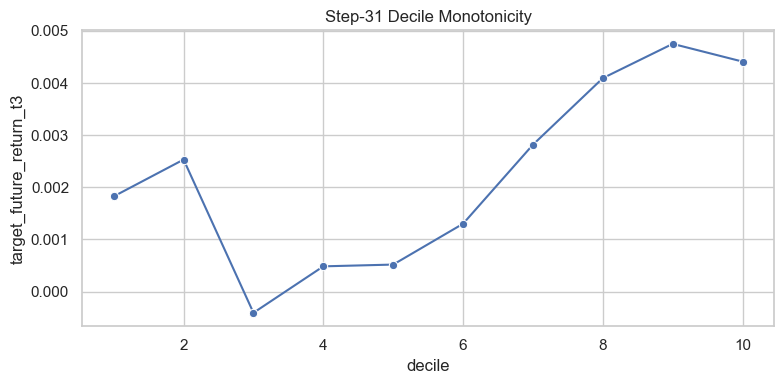

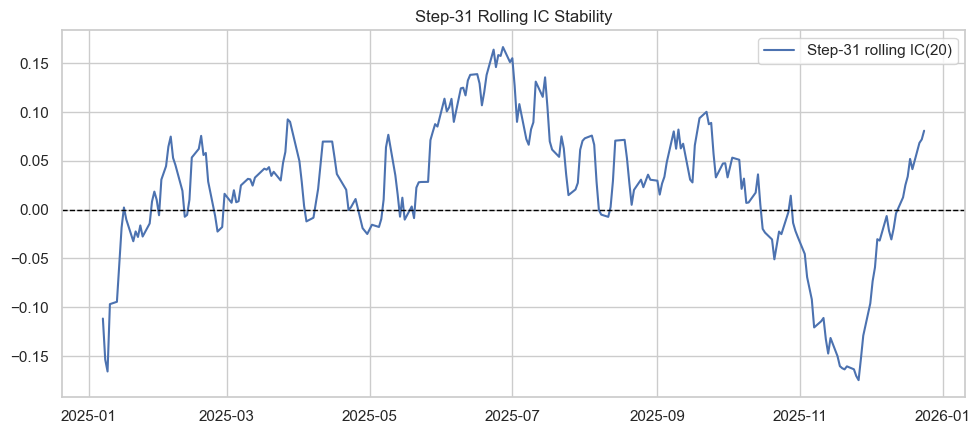

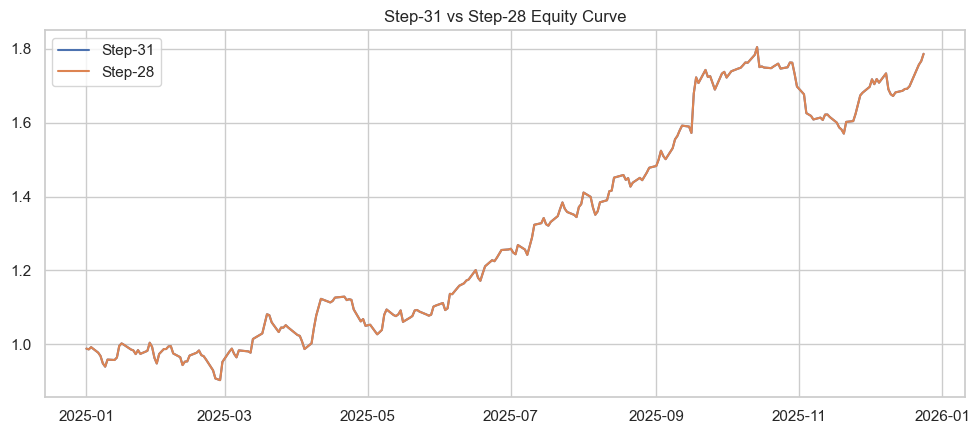

Mean IC: 0.0268
IC std: 0.2731
IC hit rate: 0.4980
Sharpe ratio: 2.6280
Final verdict: FAIL -> FALLBACK_TO_STEP28
Saved: c:\Users\Priyanshu\Desktop\Main\Financial-Marketing-Forecasting\ml_pipeline\Market_Data\final\step31_recovered_alpha.parquet


In [6]:
# STEP 7 backtest on pred_final
trades31, daily31 = long_short_top_bottom(work[['Date', 'Ticker', 'target_future_return_t3', 'pred_final']].copy(), 'pred_final', 'target_future_return_t3', TOP_N)
metrics31 = strategy_metrics(daily31)

# STEP 8 IC + stability
ic31_daily = daily_ic(work, 'pred_final', 'target_future_return_t3')
ic31_stats = summarize_ic(ic31_daily)

# Regime IC
vol_map = raw[['Date', 'Ticker', 'Volatility_20']].copy()
work_reg = work.merge(vol_map, on=['Date', 'Ticker'], how='left')
q1 = float(raw[(raw['Date'] >= TRAIN_START) & (raw['Date'] <= TRAIN_END)]['Volatility_20'].quantile(1 / 3))
q2 = float(raw[(raw['Date'] >= TRAIN_START) & (raw['Date'] <= TRAIN_END)]['Volatility_20'].quantile(2 / 3))
work_reg['Regime'] = np.where(work_reg['Volatility_20'] <= q1, 'LOW', np.where(work_reg['Volatility_20'] <= q2, 'MEDIUM', 'HIGH'))

regime_ic_rows = []
for reg in ['LOW', 'MEDIUM', 'HIGH']:
    ic_r = daily_ic(work_reg[work_reg['Regime'] == reg], 'pred_final', 'target_future_return_t3')
    s = summarize_ic(ic_r)
    regime_ic_rows.append({'Regime': reg, 'Mean_IC': s['mean_ic'], 'IC_Std': s['std_ic'], 'IC_Hit_Rate': s['hit_rate']})
regime_ic_df = pd.DataFrame(regime_ic_rows)

# STEP 9 decile monotonicity
mono = work[['Date', 'Ticker', 'pred_final', 'target_future_return_t3']].copy()
mono['decile'] = mono.groupby('Date')['pred_final'].transform(
    lambda x: pd.qcut(x.rank(method='first'), 10, labels=False, duplicates='drop') + 1 if x.nunique() >= 10 else np.nan
)
decile_ret = mono.dropna(subset=['decile']).groupby('decile', as_index=False)['target_future_return_t3'].mean()
decile_ret['decile'] = decile_ret['decile'].astype(int)
mono_spearman, _ = spearmanr(decile_ret['decile'], decile_ret['target_future_return_t3'])

# Step-28 baseline metrics
step28_ic_mean = float(step28['ic_mean_selected'].iloc[0]) if 'ic_mean_selected' in step28.columns else np.nan
step28_ic_std = float(step28['ic_std_selected'].iloc[0]) if 'ic_std_selected' in step28.columns else np.nan
step28_sharpe = float(step28['sharpe_selected'].iloc[0]) if 'sharpe_selected' in step28.columns else np.nan
step28_daily = step28[['Date', 'daily_portfolio_return']].drop_duplicates('Date').set_index('Date')['daily_portfolio_return'].sort_index()
step28_mdd = float(max_drawdown((1.0 + step28_daily).cumprod())) if len(step28_daily) else np.nan

# Step-30 diagnostics metrics
if step30 is not None and len(step30) > 0:
    step30_ic_mean = float(step30['step30_mean_ic'].dropna().iloc[0]) if 'step30_mean_ic' in step30.columns and step30['step30_mean_ic'].notna().any() else np.nan
    step30_ic_std = float(step30['step30_ic_std'].dropna().iloc[0]) if 'step30_ic_std' in step30.columns and step30['step30_ic_std'].notna().any() else np.nan
    step30_sharpe = float(step30['step30_sharpe'].dropna().iloc[0]) if 'step30_sharpe' in step30.columns and step30['step30_sharpe'].notna().any() else np.nan
    if 'daily_portfolio_return' in step30.columns:
        s30_daily = step30[['Date', 'daily_portfolio_return']].drop_duplicates('Date').set_index('Date')['daily_portfolio_return'].dropna().sort_index()
        step30_mdd = float(max_drawdown((1.0 + s30_daily).cumprod())) if len(s30_daily) else np.nan
    else:
        step30_mdd = np.nan
else:
    step30_ic_mean = np.nan
    step30_ic_std = np.nan
    step30_sharpe = np.nan
    step30_mdd = np.nan

# STEP 11 strict quality gate
candidate_pass = bool(
    (ic31_stats['mean_ic'] >= step28_ic_mean)
    and (metrics31['sharpe'] >= step28_sharpe)
    and (float(mono_spearman) > 0)
    and (ic31_stats['hit_rate'] >= 0.52)
)

if candidate_pass:
    verdict = 'PASS'
    final_signal_col = 'pred_final'
    final_daily = daily31
    final_metrics = metrics31
    final_ic_stats = ic31_stats
    final_mono = float(mono_spearman)
else:
    verdict = 'FAIL -> FALLBACK_TO_STEP28'
    work['pred_final'] = work['rank_lgb']
    work['pred_final_rank'] = work.groupby('Date')['pred_final'].rank(pct=True)
    work['pred_final_z'] = work.groupby('Date')['pred_final'].transform(cs_zscore)
    trades31, final_daily = long_short_top_bottom(work[['Date', 'Ticker', 'target_future_return_t3', 'pred_final']].copy(), 'pred_final', 'target_future_return_t3', TOP_N)
    final_metrics = strategy_metrics(final_daily)
    ic31_daily = daily_ic(work, 'pred_final', 'target_future_return_t3')
    final_ic_stats = summarize_ic(ic31_daily)
    mono = work[['Date', 'Ticker', 'pred_final', 'target_future_return_t3']].copy()
    mono['decile'] = mono.groupby('Date')['pred_final'].transform(lambda x: pd.qcut(x.rank(method='first'), 10, labels=False, duplicates='drop') + 1 if x.nunique() >= 10 else np.nan)
    decile_ret = mono.dropna(subset=['decile']).groupby('decile', as_index=False)['target_future_return_t3'].mean()
    decile_ret['decile'] = decile_ret['decile'].astype(int)
    final_mono, _ = spearmanr(decile_ret['decile'], decile_ret['target_future_return_t3'])

# STEP 10 comparison table
compare_df = pd.DataFrame([
    {'Metric': 'Mean IC', 'Step-28': step28_ic_mean, 'Step-30': step30_ic_mean, 'Step-31': final_ic_stats['mean_ic']},
    {'Metric': 'IC std', 'Step-28': step28_ic_std, 'Step-30': step30_ic_std, 'Step-31': final_ic_stats['std_ic']},
    {'Metric': 'Sharpe', 'Step-28': step28_sharpe, 'Step-30': step30_sharpe, 'Step-31': final_metrics['sharpe']},
    {'Metric': 'Max Drawdown', 'Step-28': step28_mdd, 'Step-30': step30_mdd, 'Step-31': final_metrics['max_drawdown']},
    {'Metric': 'Monotonicity', 'Step-28': np.nan, 'Step-30': np.nan, 'Step-31': float(final_mono)},
])
display(compare_df.round(4))
display(regime_ic_df.round(4))
display(decile_ret.round(5))

plt.figure(figsize=(8, 4))
sns.lineplot(data=decile_ret, x='decile', y='target_future_return_t3', marker='o')
plt.title('Step-31 Decile Monotonicity')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4.5))
if len(ic31_daily):
    plt.plot(ic31_daily['Date'], ic31_daily['IC_rolling_20'], label='Step-31 rolling IC(20)')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.title('Step-31 Rolling IC Stability')
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4.5))
plt.plot((1.0 + final_daily).cumprod(), label='Step-31')
plt.plot((1.0 + step28_daily).cumprod(), label='Step-28')
plt.title('Step-31 vs Step-28 Equity Curve')
plt.legend()
plt.tight_layout()
plt.show()

# STEP 12 save output
daily_map = final_daily.to_dict()
save_df = work.copy()
save_df['rank'] = save_df['pred_final_rank']
save_df['zscore'] = save_df['pred_final_z']
save_df['daily_strategy_return'] = save_df['Date'].map(daily_map)

trade_map = trades31[['Date', 'Ticker', 'side', 'weight', 'strategy_component']].copy()
save_df = save_df.merge(trade_map, on=['Date', 'Ticker'], how='left')

save_df['ic_mean_step31'] = final_ic_stats['mean_ic']
save_df['ic_std_step31'] = final_ic_stats['std_ic']
save_df['ic_hit_rate_step31'] = final_ic_stats['hit_rate']
save_df['sharpe_step31'] = final_metrics['sharpe']
save_df['total_return_step31'] = final_metrics['total_return']
save_df['max_drawdown_step31'] = final_metrics['max_drawdown']
save_df['monotonicity_step31'] = float(final_mono)
save_df['verdict'] = verdict
save_df['ensemble_mode'] = ensemble_mode

out_cols = [
    'Date', 'Ticker', 'target_future_return_t3',
    'pred_base', 'pred_lgb', 'pred_xgb', 'pred_xgb_refined',
    'rank_lgb', 'rank_xgb', 'rank_xgb_refined',
    'pred_final', 'rank', 'zscore',
    'weight_lgb_dynamic', 'weight_xgb_dynamic',
    'side', 'weight', 'strategy_component', 'daily_strategy_return',
    'ic_mean_step31', 'ic_std_step31', 'ic_hit_rate_step31',
    'sharpe_step31', 'total_return_step31', 'max_drawdown_step31',
    'monotonicity_step31', 'verdict', 'ensemble_mode'
]
out_cols = [c for c in out_cols if c in save_df.columns]

OUT_PATH.parent.mkdir(parents=True, exist_ok=True)
save_df[out_cols].to_parquet(OUT_PATH, index=False)

print(f"Mean IC: {final_ic_stats['mean_ic']:.4f}")
print(f"IC std: {final_ic_stats['std_ic']:.4f}")
print(f"IC hit rate: {final_ic_stats['hit_rate']:.4f}")
print(f"Sharpe ratio: {final_metrics['sharpe']:.4f}")
print(f"Final verdict: {verdict}")
print(f"Saved: {OUT_PATH}")
